# Cas d'usage

## 1 - Le besoin

Pour proposer des produits d'épargne tels que les dépôts à terme, les banques mène régulièrement des campagnes de démarchage téléphonique.

Ces campagnes sont couteuses, et peuvent dégrader la relation client si elles sont mal ciblées.

Notre objectif est d'exploiter l'IA pour déterminer quels clients sont les plus susceptibles d'accepter une offre, en fonction de son profil, et de l'historique de ses interactions avec la banque.

Démarcher sur la base de données personnelles soulèvent cependant de réelles questions éthiques et juridiques.

Notre objectif est donc de proposer un modèle prédictif qui permette de cibler les clients les plus susceptibles d'accepter une offre, tout en respectant la vie privée des clients et la réglementation en vigueur.

## 2 - Compréhension des données

Le jeu de données fourni contient 41 188 observations, 20 variables explicatives et une variable cible 'y', indiquant si le client a souscrit à un dépôt à terme (1) ou non (0).

Les variables explicatives couvrent plusieurs catégories:

| Catégorie | Variables |
|---|---|
| Données socio-démographiques | `age`, `job`, `marital`, `education` |
| Situation bancaire | `default`, `housing`, `loan` |
| Dernier contact de la campagne | `contact`, `month`, `day_of_week`, `duration` |
| Historique des campagnes | `campaign`, `pdays`, `previous`, `poutcome` |
| Contexte socio-économique | `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed` |
| Variable cible | `y` |

Ces variables décrivent le profil client, sa situation bancaire, ses interactions avec la banque, ainsi que le contexte socio-économique au moment de l'appel.
Nous pouvons déjà remarquer que certaines variables devront être surveillées du fait de leur caractère potentiellement sensible.

### 2.1 - Analyse des données

In [1]:
import pandas as pd

df = pd.read_csv("../data/bank-additional-full.csv", sep=";")
df.head()

print(f"Nombre de lignes: {df.shape[0]}")
print(f"Nombre de colonnes: {df.shape[1]}\n")

df.info()

Nombre de lignes: 41188
Nombre de colonnes: 21

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-nu

In [2]:
print("Missing values (NaN):")
print(df.isna().sum())

print("\nUnknown values:")
print((df == "unknown").sum())

Missing values (NaN):
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Unknown values:
age                  0
job                330
marital             80
education         1731
default           8597
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64


In [3]:
print("Duplicate values:")
print(df.duplicated().sum())

Duplicate values:
12


In [4]:
print("Unique values:")
print(df.nunique())


Unique values:
age                 78
job                 12
marital              4
education            8
default              3
housing              3
loan                 3
contact              2
month               10
day_of_week          5
duration          1544
campaign            42
pdays               27
previous             8
poutcome             3
emp.var.rate        10
cons.price.idx      26
cons.conf.idx       26
euribor3m          316
nr.employed         11
y                    2
dtype: int64


In [5]:
df.describe().T
df.select_dtypes(include="object").describe().T
df["y"].value_counts()
df["y"].value_counts(normalize=True).mul(100).round(2).astype(str) + '%'

y
no     88.73%
yes    11.27%
Name: proportion, dtype: object

#### Manquants
Aucune valeur manquante "NaN" n'est présente dans le jeu de donnéees.
En revanche, certaines variables catégorielles contiennent des valeurs "unknown", notamment particulièrement présente dans "default" (21% des observations !).
Supprimer ces lignes serait une perte de données importantes, il sera donc préférable pour le moment de le traiter comme une catégorie spécifique, et nous réévaluerons leur impact plus tard.

#### Doublons
Nous observons également 12 doublons, ce qui sur 41 188 observations est négligeable, et surtout rien ne nous permet ici de différencier un vrai doublon de deux clients différents disposant de caractéristiques identiques. Nous ne supprimerons donc pas ces doublons pour le moment.

#### Cible

La variable cible est très fortement déséquilivrée:
- 88.73% des clients n'ont pas souscrit à un dépôt à terme
- 11.27% des clients ont souscrit à un dépôt à terme

Ce déséquilibre devra être pris en compte lors de la modélisation.
Notamment, on ne pourra pas se baser uniquement sur l'accuracy, puisqu'un modèle ne prédisant jamais de souscription aurait une accuracy de 88.73% sans que l'information ne soit pertinente.
Nous devrons évaluer le modèle sur d'autres métriques, telles que le F1-score, la précision et le rappel.

### 2.2 - EDA ciblé

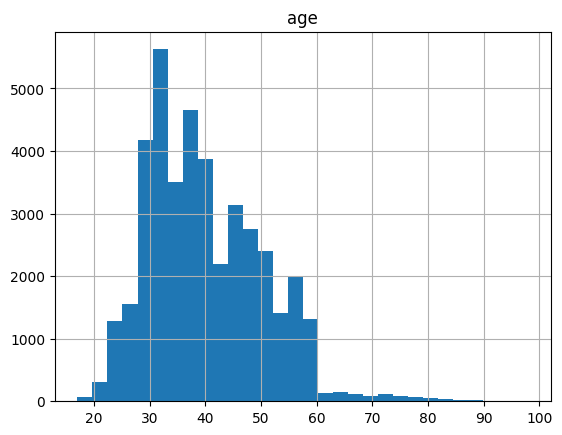

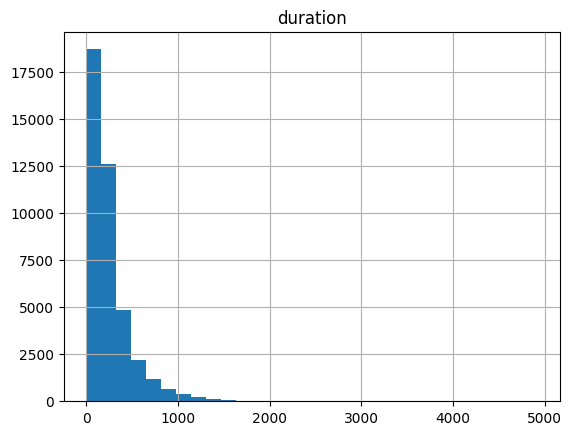

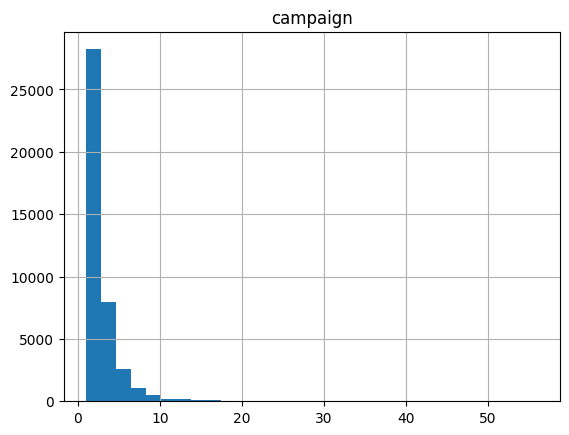

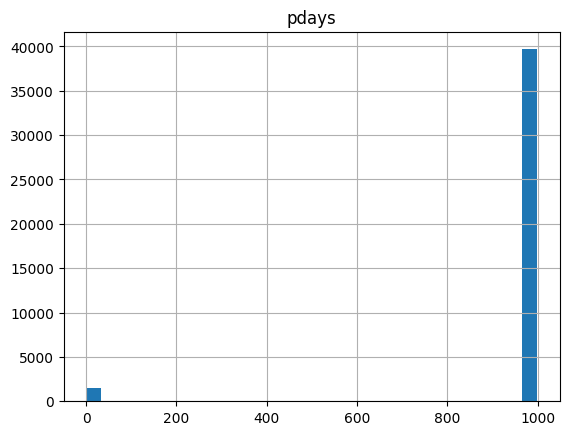

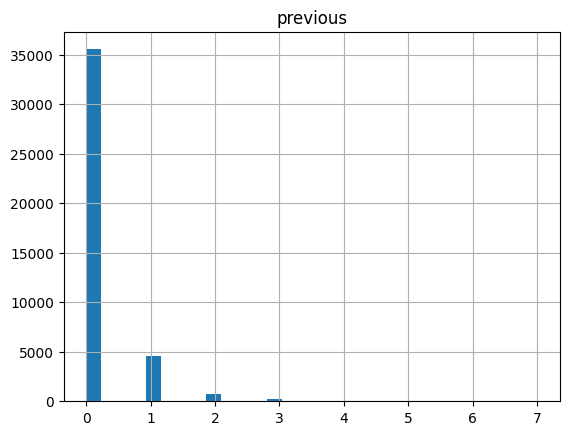

In [6]:
import matplotlib.pyplot as plt

numeric_values = ["age", "duration", "campaign", "pdays", "previous"]
for col in numeric_values:
    df[col].hist(bins=30)
    plt.title(col)
    plt.show()

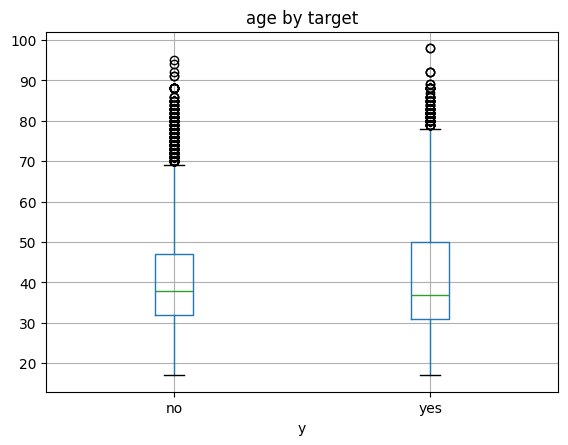

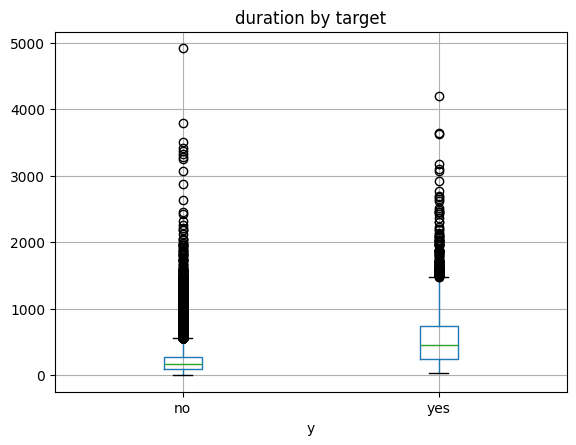

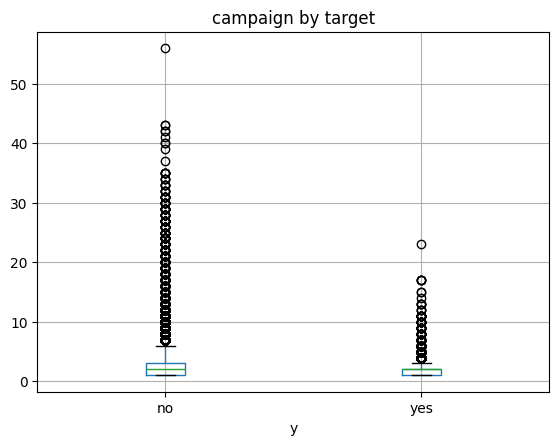

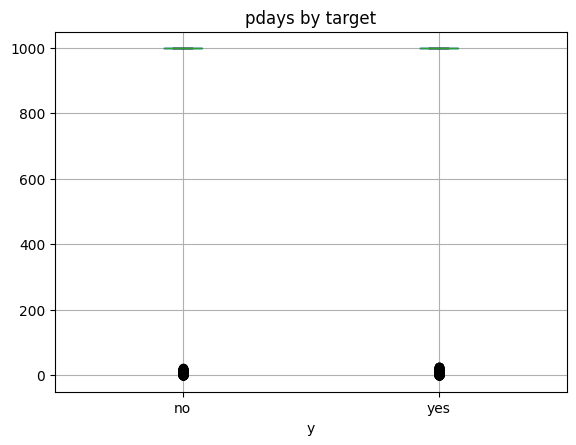

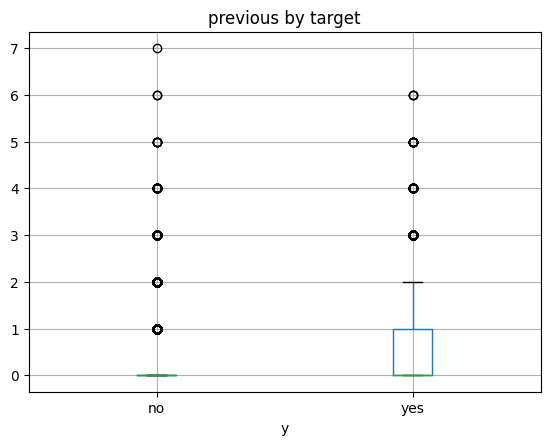

In [7]:
for col in numeric_values:
    df.boxplot(column=col, by="y")
    plt.title(f"{col} by target")
    plt.suptitle("")
    plt.show()